### LangGraph Basics

Boilerplate code to initialize LLM

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)

# test connectivity
# google_llm.invoke("hi")



Nodes, Edges and State

Defifing Nodes


In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    graph_state : str

def node_1(state : State) -> State:
    print("node_1")
    return{"graph_state":state["graph_state"]+" I am"}

def node_2(state : State) -> State:
    print("node_2")
    return{"graph_state":state["graph_state"]+" happy."}

def node_3(state : State) -> State:
    print("node_3")
    return{"graph_state":state["graph_state"]+" sad."}

def node_4(state : State) -> State:
    print("node_4")
    return{"graph_state":state["graph_state"]+" neutral."}




In [6]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2","node_3","node_4"]:
    user_input = state["graph_state"]
    ran = random.random()
    if ran < 0.3:
        return "node_2"
    if ran < 0.6:
        return "node_3"
    if ran < 1:
        return "node_4"

Build graph

In [7]:
builder = StateGraph(State)
builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
builder.add_node("node_3",node_3)
builder.add_node("node_4",node_4)

# Logic 
builder.add_edge(START,"node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2",END)
builder.add_edge("node_3",END)
builder.add_edge("node_4",END)

graph = builder.compile()

graph.invoke({"graph_state":"Hi, I'm vishwa. "})


node_1
node_2


{'graph_state': "Hi, I'm vishwa.  I am happy."}

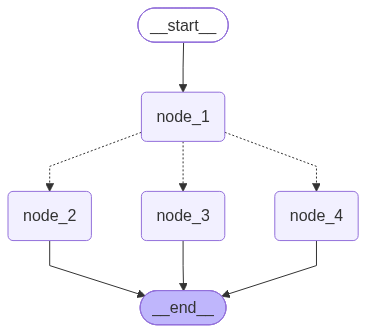

In [8]:
# printing the graph using python library
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

##### Looping the same Node
To demonstrate that updating state alone isn't enough. we've to return it


node_1
Hi I'm vishwa
node_1
Hi I'm vishwa1
node_1
Hi I'm vishwa12
node_1
Hi I'm vishwa123
node_1
Hi I'm vishwa1234


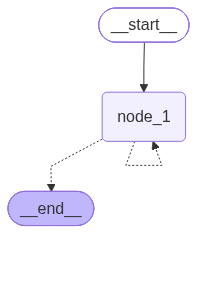

In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    graph_state : str
    num : int

num = 0

def node_1(state):
    print("node_1")
    state["num"] = state.get("num",0) + 1 # need to return must
    num = state.get("num")
    print(state["graph_state"])
    return {"graph_state":state["graph_state"] +  f"{num}","num":num}

from typing import Literal
def should_continue(state) -> Literal["node_1","__end__"]:
    if state.get("num",0) >=5:
        return "__end__"
    return "node_1"

# Build graph
builder = StateGraph(State)
builder.add_node("node_1",node_1)

# Logic
builder.add_edge(START,"node_1")
builder.add_conditional_edges("node_1",should_continue)

graph = builder.compile()

graph.invoke({"graph_state":"Hi I'm vishwa"})

from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))




